# run.009b — feature importance + block controls (which of the 76 features actually carry the signal?)

**Why:** run.009a ran the strongest, most stable signal in the project (daily-IC t = h6 +11.63 / h18 +9.18 over 42 test days) and still failed the gate on economics. Before adding features (the only lever class that has ever moved this project — run.004), we need to know **which of the 76 features the trained model actually relies on** and which are dead weight.

**What this does:** loads the trained run.009a model from Drive, rebuilds the dataset with run.009a's **exact** pipeline (cells 1–9 below are copied verbatim), and measures on the fold-3 test set:

1. **Per-feature permutation importance** — drop in h6-IC / h18-IC / h18 AP when a feature's across-sample values are shuffled.
2. **Grouped permutation importance** — the same for the three feature blocks (`v1_base`, `new_ctx`, `v3`), with across-repeat sd.
3. **Random matched-size group control** — the null for (2). For each block, permute `N_RANDOM_CONTROLS` random feature sets of the *same size* drawn from the other features. Without this, a large drop for a big block cannot be separated from the mechanical effect of removing many inputs at once.
4. **Univariate read** — Spearman IC and direction-agnostic AUC of each feature's last-timestep value, no model involved (cheap second opinion).

**Data:** mounts Drive and extracts `/content/drive/MyDrive/60days_data.tar` → `/root/btc_data` (identical to run.009a).
**Model:** `/content/drive/MyDrive/btc_lstm_run009a/lstm_run009a_h18.pt` (fold 3, 3 seeds). If absent, it retrains fold 3 with run.009a's own training loop.

**Read-out:** per-feature permutation importance is **correlation-blind** — a feature whose information is duplicated elsewhere scores low even when it matters. Use the **pooled** noise floor, read the block control before concluding anything about a block, and treat the per-feature ranking as descriptive only, not a prune list.


In [1]:
# ── Cell 1: Install and imports ───────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch',
                'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'scipy'],
               check=True)

import os, glob, gc, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# ── Cell 2: (optional) data transfer helpers — uncomment what you need ────
#!apt install sshpass -y && cd ~ && sshpass -p 'XXXXXXXXXX' sftp -r -o "StrictHostKeyChecking no" scpuser@155.207.120.2:60days_data.tar .
#from google.colab import drive
#drive.mount('/content/drive')
#!mv btc_data.tar.xz /content/drive/MyDrive/
#!ls /content/drive/MyDrive/ -l
#drive.flush_and_unmount()


In [3]:
from google.colab import drive
drive.mount('/content/drive')

!cd ~ && mkdir -p btc_data && cd btc_data && tar xvf /content/drive/MyDrive/60days_data.tar
#!cd ~/btc_data && tar xzvf ~/20day_btc_data.tar.gz
#drive.flush_and_unmount()


Mounted at /content/drive
out5.w5.eqkkl.00000.260713.csv.gz
out5.w5.eqkkl.00001.260714.csv.gz
out5.w5.eqkkl.00002.260714.csv.gz
out5.w5.eqkkl.00003.260714.csv.gz
out5.w5.eqkkl.00004.260714.csv.gz
out5.w5.eqkkl.00005.260714.csv.gz
out5.w5.eqkkl.00006.260714.csv.gz
out5.w5.eqkkl.00007.260715.csv.gz
out5.w5.eqkkl.00008.260715.csv.gz
out5.w5.eqkkl.00009.260715.csv.gz
out5.w5.eqkkl.00010.260715.csv.gz
out5.w5.eqkkl.00011.260715.csv.gz
out5.w5.eqkkl.00012.260715.csv.gz
out5.w5.eqkkl.00013.260716.csv.gz
out5.w5.eqkkl.00014.260716.csv.gz
out5.w5.eqkkl.00015.260716.csv.gz
out5.w5.eqkkl.00016.260716.csv.gz
out5.w5.eqkkl.00017.260716.csv.gz
out5.w5.eqkkl.00018.260716.csv.gz
out5.w5.eqkkl.00019.260717.csv.gz
out5.w5.eqkkl.00020.260717.csv.gz
out5.w5.eqkkl.00021.260717.csv.gz
out5.w5.eqkkl.00022.260717.csv.gz
out5.w5.eqkkl.00023.260717.csv.gz
out5.w5.eqkkl.00024.260717.csv.gz
out5.w5.eqkkl.00025.260718.csv.gz
out5.w5.eqkkl.00026.260718.csv.gz
out5.w5.eqkkl.00027.260718.csv.gz
out5.w5.eqkkl.00028.26

In [4]:
# ── Cell 3: Config ─────────────────────────────────────────────────────────

# ── CONFIGURE THESE ───────────────────────────────────────────────────────
DATA_DIR   = '/root/btc_data'
OUTPUT_DIR = '/root/btc_lstm_run009b_importance'

WINDOW_SEC  = 5           # run.009a: the collector's w5 stream (v4.1 dual-
                          # writes w15+w5; the cell-5 loader filters on this)
HORIZONS    = [6, 9, 12, 15, 18, 24]
                          # run.009a: 5s bars — run.009's [2,3,4,5,6,8] ×3, i.e.
                          # the SAME wall-clock horizons 30s–2min. h24 (2min) is
                          # the anchor (same θ → lup_24/ldn_24 comparable to
                          # run.009's lup_8/ldn_8).
H_TRADE     = 24          # importance sampling / Huber weighting / reference IC
                          # follow the least-noisy kept horizon (run.004's
                          # t=+4.8 edge was at h8@15s = 2min = h24@5s)
VOL_WINDOW  = 720         # 1h rolling window for target normalisation (5s bars)
TARGET_CLIP = 5.0         # clip |target| at 5 sigma

SEQ_LEN      = 192        # 16 min of context (unchanged wall-clock; 3× bars at 5s)
HIDDEN_DIM   = 128        # SMALL on purpose — capacity was cleared twice (run.002/003)
NUM_LAYERS   = 2
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 2048
EPOCHS       = 12
WARMUP       = 2          # linear warmup epochs before cosine decay
PATIENCE     = 5          # early stop on val AP of the two H_SEL opportunity heads
EPOCH_SAMPLE_CAP = 600_000  # train sequences drawn per epoch (weighted, w/ replacement)

# ── run.003 (kept): focus training on directional bars ──
SAMPLE_W_BASE = 0.25      # epoch-draw probability ∝ SAMPLE_W_BASE + |y_trade|
LOSS_W_ALPHA  = 1.0       # per-sample Huber weight = min(1 + α·|y_trade|, cap)
LOSS_W_CAP    = 4.0

# ── run.004 (kept): multi-seed evaluation ──
SEEDS = [0, 1, 2]         # per-fold; test score/prob = seed-ensemble mean
MIN_DAY_SAMPLES = 500     # a test day needs this many samples to enter daily-IC stats

N_FOLDS         = 4       # walk-forward folds over the last 60% of the window
TEST_START_FRAC = 0.40    # first 40% is never tested (training warmup)
VAL_FRAC        = 0.12    # tail of each training range used for early stopping
COVERAGE_MIN    = 0.60    # features with lower non-NaN coverage are excluded

MAKER_FEE = 0.0002        # per side (Binance USDT-M futures maker)
TAKER_FEE = 0.0005        # per side

# ── run.006 (kept): schema-3/4 era handling ──
V3_ERA_ONLY  = True      # restrict the analysis window to schema-3+ rows
V3_MARKER    = 'future_ofi_sum'   # first non-NaN value of this = era start
MIN_ERA_DAYS = 6         # abort if less schema-3+ data than this has accumulated
WALL_BAND    = 0.30       # collector WALL_BAND_PCT — wall dist −1 (=absent) maps here

# ── run.007: short-horizon big-move heads ──
H_SEL        = 18         # primary selective horizon (90s), pre-registered:
                          # 18×5s = 90s = run.009's h6 — wall-clock-unchanged.
                          # Rationale (run.007): closest kept horizon to run.006's
                          # best-lift h8, θ=20bp base rate stays trainable, and
                          # ~90% of a θ-touch survives to the 90s endpoint.
THETA_BY_H   = {6: 0.0015, 9: 0.0015,   # 15 bps at 30–45s: a 20 bps move inside
                12: 0.0020, 15: 0.0020, #   30–45s is near-unreachable (base ≲0.3%)
                18: 0.0020, 24: 0.0020} # 20 bps at 60–120s — same wall-clock map as run.009
POS_W_CAP    = 20.0       # BCE pos_weight = neg/pos per head, capped here
BCE_W        = 1.0        # classification loss weight vs the (frozen-form) Huber part

# ── run.007: TP/SL exit simulation (run.006's #1 lever, untested there) ──
TP_MULT      = 1.0        # primary take-profit = TP_MULT·θ_h (limit, maker exit)
SL_MULT      = 1.0        # primary stop = SL_MULT·θ_h (taker exit at the
                          # breaching bar's CLOSE — gap-through conservative)
TP_SL_GRID   = [(1.0, 1.0), (1.0, 0.5), (1.0, np.inf), (1.5, 1.0), (1.5, 0.5)]
                          # exploratory grid; ONLY (TP_MULT, SL_MULT) is gated

# ── run.007: rolling-causal trigger calibration ──
ROLL_CAL_DAYS = 14        # τ for test day D = (1−rate)-quantile of the scores
                          # seen in [D−14d, D): val seeds the window, already-
                          # seen test scores join it. Deployable (past data
                          # only); fixes run.006's fold-1 zero-trigger pathology.
MIN_CAL_N     = 5000      # thinner window → expand to all past scores

TRIGGER_RATES = [0.0001, 0.001, 0.01]  # nominal trigger rates
PRIMARY_RATE  = 0.001     # pre-registered primary: top-0.1% ≈ a few signals/day
N_BOOT        = 2000      # day-cluster bootstrap draws for net-bps CIs

# ── run.008: maker-entry simulation (run.007's diagnosed remaining lever) ──
ENTRY_WAIT   = 6          # bars the entry limit may rest before cancel
                          # (primary, pre-registered): 6×5s = 30s = run.009's
                          # wait=2 at 15s — wall-clock-unchanged; the pullback
                          # timing rationale (30s scale) is unchanged
ENTRY_DELTA  = 0.0        # limit offset in θ_h units below (up) / above (dn)
                          # the trigger close; 0 = post AT the signal close
ENTRY_DELAY  = 0          # bars between signal and posting (1 = latency stress)
WAIT_GRID    = [3, 6, 12, 18]      # exploratory (15/30/60/90s at 5s = run.009's grid)
DELTA_GRID   = [0.0, 0.25, 0.5]    # exploratory, ·θ_h
FILL_MIN     = 0.25       # gate C: primary config must fill ≥ this share of
                          # triggers — a maker edge that almost never fills is
                          # a statistical fluke, not a strategy

DRIVE_SAVE_DIR = '/content/drive/MyDrive/btc_lstm_run009b_importance'
# ─────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Data dir:   {DATA_DIR}')
print(f'Output dir: {OUTPUT_DIR}')
print('θ per horizon: ' + '  '.join(f'h{h}={t*1e4:.0f}bp' for h, t in THETA_BY_H.items()))
print(f'taker RT = {2*TAKER_FEE*1e4:.0f} bps   TP RT (taker in, maker out) = '
      f'{(TAKER_FEE+MAKER_FEE)*1e4:.0f} bps   full-maker RT = '
      f'{2*MAKER_FEE*1e4:.0f} bps')


Data dir:   /root/btc_data
Output dir: /root/btc_lstm_run009b_importance
θ per horizon: h6=15bp  h9=15bp  h12=20bp  h15=20bp  h18=20bp  h24=20bp
taker RT = 10 bps   TP RT (taker in, maker out) = 7 bps   full-maker RT = 4 bps


In [5]:
# ── Cell 4: Feature pipeline ──────────────────────────────────────────────
SEPARATOR = ';'

COLS_NEEDED_BASE = {
    'spot_datetime', 'future_datetime', 'spot_timestamp', 'future_timestamp',
    'future_bid_close', 'future_ask_close',
    'future_bid_open', 'future_bid_max', 'future_bid_min',
    'future_bid_median', 'future_ask_median',
    'future_spread_open', 'future_spread_max',
    'future_buy_qty', 'future_sell_qty',
    'future_buy_samples', 'future_sell_samples',
    'future_buy_vwap', 'future_sell_vwap', 'future_price_diff',
    'future_bid_liq_0.0_median', 'future_ask_liq_0.0_median',
    'spot_buy_qty', 'spot_sell_qty',
    'spot_bid_close', 'spot_ask_close',
    'opt_open_interest_sample', 'opt_funding_rate_sample',
    'opt_est_funding_rate_sample', 'opt_remaining_time_sample',
    'opt_long_force_exit_qty_sum', 'opt_short_force_exit_qty_sum',
    'future_first_trade_side', 'future_last_trade_side',
    'future_largest_trade_qty', 'future_largest_trade_side',
    'future_buy_count_early', 'future_buy_count_late',
    'future_sell_count_early', 'future_sell_count_late',
    'future_buy_qty_early', 'future_buy_qty_late',
    'future_sell_qty_early', 'future_sell_qty_late',
}
COLS_NEEDED_LIQ_DEEP  = [
    'future_bid_liq_0.04_median', 'future_ask_liq_0.04_median',
    'future_bid_liq_0.05_median', 'future_ask_liq_0.05_median',
    'future_bid_liq_0.06_median', 'future_ask_liq_0.06_median',
]
COLS_NEEDED_LIQ_TOTAL = [
    'future_bid_liq_0.1_median',  'future_ask_liq_0.1_median',
    'future_bid_liq_0.2_median',  'future_ask_liq_0.2_median',
    'future_bid_liq_0.3_median',  'future_ask_liq_0.3_median',
    'future_bid_liq_0.4_median',  'future_ask_liq_0.4_median',
]
# run.006: schema-3/4 collector columns (out3/out4 files; NaN in older files)
COLS_NEEDED_V3 = [
    'future_mid_std', 'future_mid_rv', 'future_mid_flips',
    'future_micro_dev_close', 'future_micro_dev_median',
    'future_ofi_sum',
    'future_add_bid_near_sum', 'future_cancel_bid_near_sum',
    'future_add_ask_near_sum', 'future_cancel_ask_near_sum',
    'future_add_bid_wide_sum', 'future_cancel_bid_wide_sum',
    'future_add_ask_wide_sum', 'future_cancel_ask_wide_sum',
    'future_depth_msg_count', 'future_best_bid_move_count',
    'future_best_ask_move_count',
    'future_bid_depletion_count', 'future_ask_depletion_count',
    'future_buy_size_median', 'future_buy_size_p90',
    'future_sell_size_median', 'future_sell_size_p90',
    'future_bid_wall_qty_median', 'future_bid_wall_qty_max',
    'future_bid_wall_dist_median',
    'future_ask_wall_qty_median', 'future_ask_wall_qty_max',
    'future_ask_wall_dist_median',
    'future_max_batch_buy_qty', 'future_max_batch_sell_qty',
    'future_max_buy_run_qty', 'future_max_sell_run_qty',
    'opt_long_force_exit_cnt_sum', 'opt_short_force_exit_cnt_sum',
    'opt_long_force_exit_notional_sum', 'opt_short_force_exit_notional_sum',
    'opt_force_exit_notional_max',
    'opt_long_short_ratio_sample',
    'opt_eth_mid_open', 'opt_eth_mid_close',
    'schema_version',
]

# run.004: long-timescale context the 64-bar input window cannot see
NEW_FEATURES = [
    'ret_norm_1h', 'ret_norm_4h', 'ret_norm_24h',
    'ma_gap_1h', 'ma_gap_4h', 'ma_gap_24h',
    'vol_ratio_1h_24h', 'range_pos_24h',
    'basis_z_4h', 'basis_mom_1h',
    'dow_sin', 'dow_cos',
]

# run.006: engineered from the schema-3/4 columns. Episodic by nature —
# mostly quiet, occasionally scream — which is the shape a rare-trigger
# model needs (v1's continuous rolling stats are why runs 001–005 came
# out diffuse).
V3_FEATURES = [
    'ofi_z', 'flow_net_near_z', 'cancel_imbal_near',
    'pull_add_bid', 'pull_add_ask', 'flow_net_widex_z',
    'micro_dev_z', 'mid_rv_norm', 'mid_flips_norm', 'msg_rate_norm',
    'depl_imbal', 'depl_total_norm',
    'buy_tail_ratio', 'sell_tail_ratio',
    'liq_cnt_log', 'liq_imbal', 'liq_notional_log', 'liq_notional_max_log',
    'wall_imbal', 'bid_wall_dist', 'ask_wall_dist', 'wall_qty_norm',
    'batch_buy_rel', 'batch_sell_rel', 'sweep_buy_rel', 'sweep_sell_rel',
    'eth_ret_z', 'eth_lead_gap', 'lsr_z',
]

ALL_FEATURES = [
    'book_imbalance', 'flow_imbalance', 'momentum', 'book_imbal_deep',
    'flow_imbal_roll4', 'flow_imbal_roll8', 'book_imbal_roll4', 'book_imbal_roll8',
    'vwap_spread', 'liq_flag', 'stochastic', 'spread_expansion', 'sample_imbalance',
    'flow_agreement', 'oi_change', 'size_imbalance', 'liq_conc_bid', 'liq_conc_ask',
    'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos',
    'near_funding', 'funding_pressure', 'vol_norm',
    'trade_side_open', 'trade_side_close', 'trade_side_momentum',
    'largest_trade_side', 'largest_trade_rel',
    'buy_accel', 'sell_accel', 'flow_accel', 'buy_count_accel', 'late_imbalance',
] + NEW_FEATURES + V3_FEATURES

# binary opportunity heads: column order is frozen here and reused everywhere
CLS_KEYS = [(h, s) for h in HORIZONS for s in ('up', 'dn')]
CLS_COLS = [f'l{s}_{h}' for h, s in CLS_KEYS]
SEL_UP_J = CLS_KEYS.index((H_SEL, 'up'))
SEL_DN_J = CLS_KEYS.index((H_SEL, 'dn'))


def load_files(files):
    all_needed = (COLS_NEEDED_BASE | set(COLS_NEEDED_LIQ_DEEP)
                  | set(COLS_NEEDED_LIQ_TOTAL) | set(COLS_NEEDED_V3))
    frames = []
    for path in files:
        try:
            hdr = pd.read_csv(path, sep=SEPARATOR, nrows=0)
            usecols = sorted(all_needed & set(hdr.columns))
            if 'spot_datetime' not in usecols:
                print(f'  SKIP {os.path.basename(path)}: missing spot_datetime')
                continue
            df = pd.read_csv(path, sep=SEPARATOR, usecols=usecols, low_memory=False)
            df = df[df['spot_datetime'] != 'spot_datetime']
            frames.append(df)
        except Exception as e:
            print(f'  SKIP {os.path.basename(path)}: {e}')
    if not frames:
        raise RuntimeError('No valid CSV files found.')
    print(f'  Loaded {len(frames)} files')
    return pd.concat(frames, ignore_index=True)


def prepare(df, horizons, vol_window):
    df['dt'] = pd.to_datetime(df['spot_datetime'], errors='coerce')
    df = df.dropna(subset=['dt']).sort_values('dt').reset_index(drop=True)
    n_before = len(df)
    df = df.drop_duplicates(subset='dt', keep='first').reset_index(drop=True)
    if len(df) < n_before:
        print(f'  Dropped {n_before - len(df)} duplicate timestamps')

    skip = {'spot_datetime', 'future_datetime', 'dt'}
    for col in df.columns:
        if col not in skip:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in [c for c in df.columns if c.startswith('opt_')]:
        df[col] = df[col].replace(-1, np.nan)

    if 'future_bid_close' in df.columns and 'future_ask_close' in df.columns:
        df['close_price'] = (df['future_bid_close'] + df['future_ask_close']) / 2.0
    else:
        df['close_price'] = (df['future_bid_median'] + df['future_ask_median']) / 2.0

    # Gap structure: collector restarts / dropped bars break the WINDOW_SEC cadence.
    gap = df['dt'].diff().dt.total_seconds()
    n_breaks = int((gap != WINDOW_SEC).sum()) - 1
    big = gap[gap > 3600]
    print(f'  Cadence breaks: {n_breaks}  (gaps >1h: {len(big)}, largest: {gap.max()/3600:.1f}h)')

    eps = 1e-9
    df['flow_imbalance'] = ((df['future_buy_qty'] - df['future_sell_qty']) /
                            (df['future_buy_qty'] + df['future_sell_qty'] + eps))
    bid0 = df['future_bid_liq_0.0_median']
    ask0 = df['future_ask_liq_0.0_median']
    df['book_imbalance'] = (bid0 - ask0) / (bid0 + ask0 + eps)
    df['momentum'] = df['future_price_diff']

    deep_col = None
    for lvl in ['0.05', '0.04', '0.06']:
        b, a = f'future_bid_liq_{lvl}_median', f'future_ask_liq_{lvl}_median'
        if b in df.columns and a in df.columns:
            deep_col = (b, a); break
    df['book_imbal_deep'] = ((df[deep_col[0]] - df[deep_col[1]]) /
                             (df[deep_col[0]] + df[deep_col[1]] + eps)) if deep_col else np.nan

    # run.009a (5s): bar-count rollers ×3 to keep run.009's wall-clock
    # meaning (60s/120s); feature NAMES kept so ALL_FEATURES is untouched
    df['flow_imbal_roll4'] = df['flow_imbalance'].rolling(12, min_periods=6).mean()
    df['flow_imbal_roll8'] = df['flow_imbalance'].rolling(24, min_periods=12).mean()
    df['book_imbal_roll4'] = df['book_imbalance'].rolling(12, min_periods=6).mean()
    df['book_imbal_roll8'] = df['book_imbalance'].rolling(24, min_periods=12).mean()

    df['vwap_spread'] = (df['future_buy_vwap'] - df['future_sell_vwap']
                         if 'future_buy_vwap' in df.columns else np.nan)
    liq_long  = df.get('opt_long_force_exit_qty_sum',  pd.Series(0, index=df.index))
    liq_short = df.get('opt_short_force_exit_qty_sum', pd.Series(0, index=df.index))
    df['liq_flag'] = ((liq_long + liq_short) > 0).astype(float)

    if all(c in df.columns for c in ['future_bid_max', 'future_bid_min', 'future_bid_close']):
        rng = df['future_bid_max'] - df['future_bid_min']
        df['stochastic'] = np.where(rng > 0, (df['future_bid_close'] - df['future_bid_min']) / rng, 0.5)
    else:
        df['stochastic'] = np.nan

    df['spread_expansion'] = (df['future_spread_max'] - df['future_spread_open']
                              if all(c in df.columns for c in ['future_spread_max', 'future_spread_open'])
                              else np.nan)

    if all(c in df.columns for c in ['future_buy_samples', 'future_sell_samples']):
        bs, ss = df['future_buy_samples'], df['future_sell_samples']
        df['sample_imbalance'] = (bs - ss) / (bs + ss + eps)
    else:
        df['sample_imbalance'] = np.nan

    if all(c in df.columns for c in ['spot_buy_qty', 'spot_sell_qty']):
        spot_flow = ((df['spot_buy_qty'] - df['spot_sell_qty']) /
                     (df['spot_buy_qty'] + df['spot_sell_qty'] + eps))
        df['flow_agreement'] = df['flow_imbalance'] * spot_flow
    else:
        df['flow_agreement'] = np.nan

    df['oi_change'] = df['opt_open_interest_sample'].diff() if 'opt_open_interest_sample' in df.columns else np.nan

    if all(c in df.columns for c in ['future_buy_samples', 'future_sell_samples',
                                      'future_buy_qty', 'future_sell_qty']):
        df['size_imbalance'] = (df['future_buy_qty']  / (df['future_buy_samples']  + eps) -
                                df['future_sell_qty'] / (df['future_sell_samples'] + eps))
    else:
        df['size_imbalance'] = np.nan

    sub_cols = ['future_first_trade_side', 'future_last_trade_side',
                'future_largest_trade_qty', 'future_largest_trade_side',
                'future_buy_count_early', 'future_buy_count_late',
                'future_sell_count_early', 'future_sell_count_late',
                'future_buy_qty_early', 'future_buy_qty_late',
                'future_sell_qty_early', 'future_sell_qty_late']
    if all(c in df.columns for c in sub_cols):
        bqe, bql = df['future_buy_qty_early'],  df['future_buy_qty_late']
        sqe, sql = df['future_sell_qty_early'],  df['future_sell_qty_late']
        fts, lts = df['future_first_trade_side'], df['future_last_trade_side']
        lq,  ls  = df['future_largest_trade_qty'], df['future_largest_trade_side']
        bce, bcl = df['future_buy_count_early'], df['future_buy_count_late']
        total_vol = bqe + bql + sqe + sql
        df['trade_side_open']     = fts
        df['trade_side_close']    = lts
        df['trade_side_momentum'] = lts - fts
        df['largest_trade_side']  = ls
        df['largest_trade_rel']   = lq / (total_vol + eps)
        df['buy_accel']           = bql - bqe
        df['sell_accel']          = sql - sqe
        df['flow_accel']          = (bql - sql) - (bqe - sqe)
        df['buy_count_accel']     = bcl - bce
        df['late_imbalance']      = (bql - sql) / (bql + sql + eps)
    else:
        for c in ['trade_side_open','trade_side_close','trade_side_momentum',
                  'largest_trade_side','largest_trade_rel','buy_accel','sell_accel',
                  'flow_accel','buy_count_accel','late_imbalance']:
            df[c] = np.nan

    deep_bid = next((c for c in ['future_bid_liq_0.4_median','future_bid_liq_0.3_median',
                                  'future_bid_liq_0.2_median','future_bid_liq_0.1_median']
                     if c in df.columns), None)
    deep_ask = next((c for c in ['future_ask_liq_0.4_median','future_ask_liq_0.3_median',
                                  'future_ask_liq_0.2_median','future_ask_liq_0.1_median']
                     if c in df.columns), None)
    df['liq_conc_bid'] = (df['future_bid_liq_0.0_median'] / (df[deep_bid] + eps)
                          if deep_bid else np.nan)
    df['liq_conc_ask'] = (df['future_ask_liq_0.0_median'] / (df[deep_ask] + eps)
                          if deep_ask else np.nan)

    hour, minute = df['dt'].dt.hour, df['dt'].dt.minute
    df['hour_sin']   = np.sin(2 * np.pi * hour   / 24)
    df['hour_cos']   = np.cos(2 * np.pi * hour   / 24)
    df['minute_sin'] = np.sin(2 * np.pi * minute / 60)
    df['minute_cos'] = np.cos(2 * np.pi * minute / 60)

    secs = (hour * 3600 + minute * 60 + df['dt'].dt.second) % (8 * 3600)
    df['near_funding'] = ((8 * 3600 - secs) < 900).astype(float)
    if 'opt_funding_rate_sample' in df.columns:
        funding = df['opt_funding_rate_sample'].replace(-1, np.nan).fillna(0)
        df['funding_pressure'] = funding * df['near_funding']
    else:
        df['funding_pressure'] = np.nan

    # run.009a (5s): 4-min volatility (48 bars) vs its 24h mean (17280 bars)
    df['volatility'] = df['close_price'].diff().abs().rolling(48, min_periods=12).mean()
    df['vol_norm']   = (df['volatility'] /
                        df['volatility'].rolling(17280, min_periods=288).mean()
                       ).replace([np.inf, -np.inf], np.nan)

    # ── run.004: long-timescale context features ─────────────────────────
    # All rolling windows are TIME-based on the datetime index (rolling('24h')),
    # not row-count based: collector restarts land on arbitrary second offsets
    # and gaps would otherwise stretch a "1h" window over more wall time.
    # Everything is causal (past data only) and vol-normalised so the scale is
    # stationary across regimes; clipped at ±8 to bound scaler-era outliers.
    D = 24 * 3600 // WINDOW_SEC              # bars per 24h at full cadence
    lp = pd.Series(np.log(df['close_price'].values), index=df['dt'])

    def past(series, delta, tol_sec=2 * WINDOW_SEC):
        # value of `series` ~delta earlier (nearest bar within tol), aligned back
        p = series.reindex(series.index - delta, method='nearest',
                           tolerance=pd.Timedelta(seconds=tol_sec))
        return pd.Series(p.values, index=series.index)

    r1 = lp.diff()
    r1[gap.values != WINDOW_SEC] = np.nan    # 1-bar return across a gap is not 1-bar
    sigma24 = r1.rolling('24h', min_periods=D // 4).std()

    for name, td, W in [('1h', pd.Timedelta(hours=1),  D // 24),
                        ('4h', pd.Timedelta(hours=4),  D // 6),
                        ('24h', pd.Timedelta(hours=24), D)]:
        unit = sigma24 * np.sqrt(W) + eps
        df[f'ret_norm_{name}'] = ((lp - past(lp, td)) / unit).clip(-8, 8).values
        ma = lp.rolling(td, min_periods=int(W * 0.75)).mean()
        df[f'ma_gap_{name}'] = ((lp - ma) / unit).clip(-8, 8).values

    vol1h = r1.rolling('1h', min_periods=D // 48).std()
    df['vol_ratio_1h_24h'] = (vol1h / (sigma24 + eps)).clip(0, 5).values

    hi24 = lp.rolling('24h', min_periods=D // 4).max()
    lo24 = lp.rolling('24h', min_periods=D // 4).min()
    df['range_pos_24h'] = ((lp - lo24) / (hi24 - lo24 + eps)).clip(0, 1).values

    if all(c in df.columns for c in ['spot_bid_close', 'spot_ask_close']):
        spot_mid = (df['spot_bid_close'] + df['spot_ask_close']) / 2.0
        basis = pd.Series(((df['close_price'] - spot_mid) / (spot_mid + eps)).values,
                          index=df['dt'])
        b_ma = basis.rolling('4h', min_periods=D // 12).mean()
        b_sd = basis.rolling('4h', min_periods=D // 12).std()
        df['basis_z_4h'] = ((basis - b_ma) / (b_sd + eps)).clip(-8, 8).values
        b_mom = basis - past(basis, pd.Timedelta(hours=1))
        b_mom_sd = b_mom.rolling('4h', min_periods=D // 12).std()
        df['basis_mom_1h'] = (b_mom / (b_mom_sd + eps)).clip(-8, 8).values
    else:
        df['basis_z_4h'] = np.nan
        df['basis_mom_1h'] = np.nan

    dow = df['dt'].dt.dayofweek
    df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

    # ── run.006: schema-3/4 microstructure features ──────────────────────
    # Same conventions as the run.004 block: causal time-based rollers,
    # z-scores clipped ±8, ratios clipped [0, 10]. Every group is guarded on
    # column presence so pre-v3 files simply yield NaN (the era slice and the
    # coverage guard in the next cell handle the rest).
    mp1h = D // 24                                    # 1h of bars = min_periods

    def _ts(x):
        return pd.Series(np.asarray(x, dtype=np.float64), index=df['dt'])

    def roll_z(x, win='4h', mp=mp1h):
        s = _ts(x)
        return ((s - s.rolling(win, min_periods=mp).mean()) /
                (s.rolling(win, min_periods=mp).std() + eps)).clip(-8, 8).values

    def roll_ratio(x, win='4h', mp=mp1h, hi=10.0):
        s = _ts(x)
        return (s / (s.rolling(win, min_periods=mp).mean() + eps)).clip(0, hi).values

    have = set(df.columns)

    df['ofi_z'] = roll_z(df['future_ofi_sum']) if 'future_ofi_sum' in have else np.nan

    flow_near = ['future_add_bid_near_sum', 'future_cancel_bid_near_sum',
                 'future_add_ask_near_sum', 'future_cancel_ask_near_sum']
    if set(flow_near) <= have:
        ab, cb = df[flow_near[0]], df[flow_near[1]]
        aa, ca = df[flow_near[2]], df[flow_near[3]]
        df['flow_net_near_z']   = roll_z((ab - cb) - (aa - ca))
        df['cancel_imbal_near'] = ((cb - ca) / (cb + ca + eps)).values
        # bid pulled faster than replenished = support evaporating (log-diff
        # is scale-free, so no rolling normalisation needed)
        df['pull_add_bid'] = (np.log1p(cb) - np.log1p(ab)).clip(-8, 8)
        df['pull_add_ask'] = (np.log1p(ca) - np.log1p(aa)).clip(-8, 8)
    else:
        for c in ['flow_net_near_z', 'cancel_imbal_near', 'pull_add_bid', 'pull_add_ask']:
            df[c] = np.nan

    flow_wide = ['future_add_bid_wide_sum', 'future_cancel_bid_wide_sum',
                 'future_add_ask_wide_sum', 'future_cancel_ask_wide_sum']
    if set(flow_wide) <= have and set(flow_near) <= have:
        # the wide band INCLUDES the near band by construction — subtract to
        # get the 0.05–0.25% ring only (schema-4 files; NaN in out3 hours)
        abx = (df[flow_wide[0]] - df[flow_near[0]]).clip(lower=0)
        cbx = (df[flow_wide[1]] - df[flow_near[1]]).clip(lower=0)
        aax = (df[flow_wide[2]] - df[flow_near[2]]).clip(lower=0)
        cax = (df[flow_wide[3]] - df[flow_near[3]]).clip(lower=0)
        df['flow_net_widex_z'] = roll_z((abx - cbx) - (aax - cax))
    else:
        df['flow_net_widex_z'] = np.nan

    df['micro_dev_z'] = (roll_z(df['future_micro_dev_close'])
                         if 'future_micro_dev_close' in have else np.nan)
    df['mid_rv_norm']    = roll_ratio(df['future_mid_rv'])    if 'future_mid_rv'    in have else np.nan
    df['mid_flips_norm'] = roll_ratio(df['future_mid_flips']) if 'future_mid_flips' in have else np.nan
    df['msg_rate_norm']  = (roll_ratio(df['future_depth_msg_count'])
                            if 'future_depth_msg_count' in have else np.nan)

    if {'future_bid_depletion_count', 'future_ask_depletion_count'} <= have:
        bd, ad = df['future_bid_depletion_count'], df['future_ask_depletion_count']
        df['depl_imbal']      = ((bd - ad) / (bd + ad + 1.0)).values
        df['depl_total_norm'] = roll_ratio(bd + ad)
    else:
        df['depl_imbal'] = np.nan
        df['depl_total_norm'] = np.nan

    for side in ('buy', 'sell'):
        med, p90 = f'future_{side}_size_median', f'future_{side}_size_p90'
        if {med, p90} <= have:
            # fat right tail at equal volume = informed flow; log1p of the
            # ratio is scale-free across the BTC-qty drift
            df[f'{side}_tail_ratio'] = np.log1p((df[p90] / (df[med] + eps)).clip(0, 100))
        else:
            df[f'{side}_tail_ratio'] = np.nan

    # liquidations: an absent liquidation IS zero, so cnt/notional NaNs are
    # filled with 0 — but only inside the schema-3+ era, so the coverage
    # guard still sees pre-v3 rows as missing.
    m3 = df['future_ofi_sum'].notna() if 'future_ofi_sum' in have else pd.Series(False, index=df.index)
    liq_cols = ['opt_long_force_exit_cnt_sum', 'opt_short_force_exit_cnt_sum',
                'opt_long_force_exit_notional_sum', 'opt_short_force_exit_notional_sum',
                'opt_force_exit_notional_max']
    for c in liq_cols:
        if c in have:
            df.loc[m3, c] = df.loc[m3, c].fillna(0)
    if {'opt_long_force_exit_cnt_sum', 'opt_short_force_exit_cnt_sum'} <= have:
        df['liq_cnt_log'] = np.log1p(df['opt_long_force_exit_cnt_sum'] +
                                     df['opt_short_force_exit_cnt_sum'])
    else:
        df['liq_cnt_log'] = np.nan
    lqf = df.get('opt_long_force_exit_qty_sum',  pd.Series(np.nan, index=df.index)).fillna(0)
    sqf = df.get('opt_short_force_exit_qty_sum', pd.Series(np.nan, index=df.index)).fillna(0)
    df['liq_imbal'] = ((lqf - sqf) / (lqf + sqf + eps)).values
    if {'opt_long_force_exit_notional_sum', 'opt_short_force_exit_notional_sum'} <= have:
        df['liq_notional_log'] = np.log1p(df['opt_long_force_exit_notional_sum'] +
                                          df['opt_short_force_exit_notional_sum'])
    else:
        df['liq_notional_log'] = np.nan
    df['liq_notional_max_log'] = (np.log1p(df['opt_force_exit_notional_max'])
                                  if 'opt_force_exit_notional_max' in have else np.nan)

    wall_cols = ['future_bid_wall_qty_median', 'future_ask_wall_qty_median',
                 'future_bid_wall_dist_median', 'future_ask_wall_dist_median']
    if set(wall_cols) <= have:
        bq, aq = df[wall_cols[0]], df[wall_cols[1]]
        df['wall_imbal'] = ((bq - aq) / (bq + aq + eps)).values
        # dist −1 = no level in band → map to the band edge ("wall absent" =
        # "as far away as possible"); qty 0 already carries the absence signal
        df['bid_wall_dist'] = df[wall_cols[2]].where(df[wall_cols[2]] >= 0, WALL_BAND)
        df['ask_wall_dist'] = df[wall_cols[3]].where(df[wall_cols[3]] >= 0, WALL_BAND)
        df['wall_qty_norm'] = roll_ratio(bq + aq)
    else:
        for c in ['wall_imbal', 'bid_wall_dist', 'ask_wall_dist', 'wall_qty_norm']:
            df[c] = np.nan

    if {'future_max_batch_buy_qty', 'future_max_buy_run_qty'} <= have:
        # concentration of the bar's volume in one 200ms burst / one same-side
        # sweep run — bounded [0,1] per side, no normalisation needed
        df['batch_buy_rel']  = (df['future_max_batch_buy_qty']  / (df['future_buy_qty']  + eps)).clip(0, 1)
        df['batch_sell_rel'] = (df['future_max_batch_sell_qty'] / (df['future_sell_qty'] + eps)).clip(0, 1)
        df['sweep_buy_rel']  = (df['future_max_buy_run_qty']    / (df['future_buy_qty']  + eps)).clip(0, 1)
        df['sweep_sell_rel'] = (df['future_max_sell_run_qty']   / (df['future_sell_qty'] + eps)).clip(0, 1)
    else:
        for c in ['batch_buy_rel', 'batch_sell_rel', 'sweep_buy_rel', 'sweep_sell_rel']:
            df[c] = np.nan

    if {'opt_eth_mid_open', 'opt_eth_mid_close'} <= have:
        eo, ec = df['opt_eth_mid_open'], df['opt_eth_mid_close']
        eth_ret = pd.Series(np.where((eo > 0) & (ec > 0), np.log(ec / eo), np.nan),
                            index=df['dt'])
        df['eth_ret_z'] = (eth_ret / (eth_ret.rolling('4h', min_periods=mp1h).std() + eps)
                           ).clip(-8, 8).values
        # ETH ran but BTC has not (yet): 1-min cumulative z-gap
        # (run.009a: 12 bars = 1 min at 5s)
        er4 = eth_ret.rolling(12, min_periods=12).sum()
        br4 = r1.rolling(12, min_periods=12).sum()
        er4z = er4 / (er4.rolling('4h', min_periods=mp1h).std() + eps)
        br4z = br4 / (br4.rolling('4h', min_periods=mp1h).std() + eps)
        df['eth_lead_gap'] = (er4z - br4z).clip(-8, 8).values
    else:
        df['eth_ret_z'] = np.nan
        df['eth_lead_gap'] = np.nan

    df['lsr_z'] = (roll_z(df['opt_long_short_ratio_sample'], '24h', D // 4)
                   if 'opt_long_short_ratio_sample' in have else np.nan)

    # Scattered-NaN guard: a sample needs SEQ_LEN contiguous surviving rows behind
    # it and MAX_H ahead, so a feature with even ~2% RANDOMLY scattered NaNs
    # (an ETH bar with no data, a missing long/short-ratio sample, a 4-bar
    # rolling gap echo) would wipe out most valid samples via dropna. These
    # per-bar signals are neutral-at-0 by construction (z-scores / gaps), so
    # fill them with 0 inside the schema-3+ era; warmup and pre-era rows stay
    # NaN so the coverage guard still sees them.
    for c in ['eth_ret_z', 'eth_lead_gap', 'lsr_z']:
        bad = m3 & df[c].isna() & (df['dt'] > df.loc[m3, 'dt'].iloc[0] +
                                   pd.Timedelta('24h')) if m3.any() else None
        if bad is not None:
            df.loc[bad, c] = 0.0

    del lp, r1, sigma24, vol1h, hi24, lo24
    # ──────────────────────────────────────────────────────────────────────

    # Targets: volatility-normalised future return per horizon. A target is
    # valid only when the row h bars ahead really is h*WINDOW_SEC ahead — no labels
    # across collector gaps. vol uses only past prices (no leakage).
    # (datetime64[s] cast is robust to the pandas 2/3 resolution change)
    dt_sec = pd.Series(df['dt'].values.astype('datetime64[s]').astype(np.int64),
                       index=df.index)
    for h in horizons:
        vol   = df['close_price'].diff(h).rolling(vol_window, min_periods=vol_window // 4).std()
        delta = df['close_price'].shift(-h) - df['close_price']
        y     = (delta / (vol + eps)).clip(-TARGET_CLIP, TARGET_CLIP)
        valid = (dt_sec.shift(-h) - dt_sec) == h * WINDOW_SEC
        y[~valid.fillna(False)] = np.nan
        df[f'y_{h}'] = y

    # ── run.009: triple-barrier FIRST-TOUCH labels ───────────────────────
    # run.006/007/008 used a pure MFE-touch label (lup=1 if +θ reached
    # ANYWHERE in the next h bars, IGNORING whether −θ was hit first) —
    # mislabelling exactly the paths the TP/SL sim loses on (a dip to −θ is
    # a taker SL fill at −30 bp; a later recovery to +θ was still counted a
    # "win"). run.008's gate failed via adverse selection (hit_m ≫ hit_f);
    # this aligns label↔payoff: lup_h = 1 iff +θ is touched STRICTLY BEFORE
    # −θ within the next h bars; ldn_h mirrors. Neither-touched or a tie →
    # 0/0 ("no idea"). Same h·WINDOW_SEC gap-validity rule as the regression
    # targets (an exact h·WINDOW_SEC span to row i+h implies every intermediate bar
    # is present). Vectorized (n×h booleans, h≤24 → RAM-safe); validated ==
    # per-row brute force over 3000 randomized gapped paths (test_first_touch.py).
    cvals = df['close_price'].values.astype(np.float64)
    n_rows = len(cvals)
    for h in horizons:
        lup = np.full(n_rows, np.nan)
        ldn = np.full(n_rows, np.nan)
        if n_rows > h:
            wv   = np.lib.stride_tricks.sliding_window_view(cvals, h)[1:]  # wv[i]=cvals[i+1:i+1+h]
            base = cvals[:n_rows - h][:, None]
            th   = THETA_BY_H[h]
            up_hit = (wv / base - 1.0) >= th          # (n_win × h) booleans
            dn_hit = (1.0 - wv / base) >= th
            t_up = np.where(up_hit.any(1), up_hit.argmax(1), h)   # first touch bar; h = never
            t_dn = np.where(dn_hit.any(1), dn_hit.argmax(1), h)
            lup[:n_rows - h] = (t_up < t_dn).astype(np.float32)   # up strictly first
            ldn[:n_rows - h] = (t_dn < t_up).astype(np.float32)   # dn strictly first
        valid = ((dt_sec.shift(-h) - dt_sec) == h * WINDOW_SEC).fillna(False).values
        df[f'lup_{h}'] = np.where(valid, lup, np.nan)
        df[f'ldn_{h}'] = np.where(valid, ldn, np.nan)
    return df

print('Feature pipeline loaded.')
print(f'Binary heads: {CLS_COLS}')


Feature pipeline loaded.
Binary heads: ['lup_6', 'ldn_6', 'lup_9', 'ldn_9', 'lup_12', 'ldn_12', 'lup_15', 'ldn_15', 'lup_18', 'ldn_18', 'lup_24', 'ldn_24']


In [6]:
# ── Cell 5: Load data, era slice, coverage guard, build arrays ────────────
# run.009a: ONLY the w{WINDOW_SEC}s stream — the v4.1 collector dual-writes
# w15 and w5 files; without this filter a mixed tar would silently interleave
# the two cadences (sorting by dt mixes 5s and 15s bars into garbage).
files = sorted(f for f in (glob.glob(os.path.join(DATA_DIR, '*.csv')) +
                           glob.glob(os.path.join(DATA_DIR, '*.csv.gz')))
               if f'.w{WINDOW_SEC}.' in os.path.basename(f))
print(f'Found {len(files)} files (w{WINDOW_SEC} only)')

raw = load_files(files)
print(f'Total rows loaded: {len(raw):,}')

df = prepare(raw, HORIZONS, VOL_WINDOW)
del raw; gc.collect()

# ── run.006: restrict the analysis window to the schema-3+ era ───────────
# The v3 features only exist where the v3/v4 collector ran; over the full
# ~13-month range they would all fail the coverage guard. Features are
# computed on the FULL frame first (so the 24h rollers are warm at the era
# boundary), then the frame is sliced.
if V3_ERA_ONLY:
    mark = (df[V3_MARKER].notna() if V3_MARKER in df.columns
            else pd.Series(False, index=df.index))
    assert mark.any(), (
        f'No schema-3 data found ({V3_MARKER} entirely missing). Either the '
        f'out3/out4 files are not in btc_data.tar.xz — rebuild the tar — or '
        f'set V3_ERA_ONLY = False to run on v1 features only.')
    v3_start = df.loc[mark, 'dt'].iloc[0]
    era_days = (df['dt'].iloc[-1] - v3_start).total_seconds() / 86400
    n_pre = int((df['dt'] < v3_start).sum())
    print(f'\nSchema-3+ era starts {v3_start}  ({era_days:.1f} days, '
          f'dropping {n_pre:,} pre-era rows)')
    assert era_days >= MIN_ERA_DAYS, (
        f'Only {era_days:.1f} days of schema-3+ data (< {MIN_ERA_DAYS}). '
        f'Let the collector accumulate more before running run.006.')
    df = df[df['dt'] >= v3_start].reset_index(drop=True)
    if 'schema_version' in df.columns:
        sv = df['schema_version']
        print('  schema mix: ' + '  '.join(
            f'v{int(v)}: {(sv == v).mean()*100:.1f}%' for v in sorted(sv.dropna().unique())))

# Coverage guard (within the analysis window): schema-4-only columns (wide
# band, walls, bursts, ETH) are NaN in out3 hours; anything below
# COVERAGE_MIN is excluded rather than letting dropna() eat the window.
features = []
for f_ in ALL_FEATURES:
    if f_ not in df.columns:
        continue
    cov = df[f_].notna().mean()
    if cov >= COVERAGE_MIN:
        features.append(f_)
    else:
        print(f'  EXCLUDED {f_:22s} coverage {cov*100:5.1f}% < {COVERAGE_MIN*100:.0f}%')
kept_v3 = [f_ for f_ in features if f_ in V3_FEATURES]
print(f'Features kept: {len(features)}/{len(ALL_FEATURES)} '
      f'(schema-3/4: {len(kept_v3)}/{len(V3_FEATURES)})')
# run.006 is built to test the schema-3/4 features, but it degrades to the
# v1 feature subset when those columns are absent (v1 collector files, or a
# btc_data.tar.xz that dropped the out3/out4 files) instead of aborting.
V3_AVAILABLE = len(kept_v3) >= 10
if not V3_AVAILABLE:
    print(f'\n*** v1-compat mode: only {len(kept_v3)}/{len(V3_FEATURES)} schema-3/4 '
          f'features present ***')
    print('    The loaded files predate the schema-3/4 collector (no future_ofi_sum, '
          'walls, ETH lead-lag, ...),')
    print('    so the selective/opportunity heads train on the v1 feature subset only. '
          'This does NOT')
    print('    test run.006\'s schema-3/4 hypothesis — it reruns the run.004/005 feature '
          'set under the')
    print('    selective objective. Feed out3/out4 files (rebuild btc_data.tar.xz) for '
          'the intended run.')

n0 = len(df)
clean = df[features + [f'y_{h}' for h in HORIZONS] + CLS_COLS + ['dt', 'close_price']] \
          .dropna(subset=features).reset_index(drop=True)
lost = n0 - len(clean)
print(f'Rows: {n0:,} → {len(clean):,} after dropna ({lost/max(n0,1)*100:.2f}% dropped)')
if lost > 0.05 * n0:
    print('\n*** WARNING: dropna removed >5% of rows — check per-feature NaN fractions: ***')
    print(df[features].isna().mean().sort_values(ascending=False).head(10))
del df; gc.collect()

X_raw  = clean[features].values.astype(np.float32)
Y_all  = np.stack([clean[f'y_{h}'].values for h in HORIZONS], axis=1).astype(np.float32)
L_all  = np.stack([clean[c].values for c in CLS_COLS], axis=1).astype(np.float32)
dt_s   = clean['dt'].values.astype('datetime64[s]').astype(np.int64)
dt_all = clean['dt'].values
close  = clean['close_price'].values.astype(np.float64)
n, F_DIM = X_raw.shape
del clean; gc.collect()

# A sample "ends" at row i: input window = rows [i-SEQ_LEN+1, i], targets and
# labels at/through i+h. Backward validity: the window must be contiguous
# WINDOW_SEC-spaced bars. Forward validity: row i+MAX_H exactly MAX_H·WINDOW_SEC ahead IN THIS
# (post-dropna) array — dropna can remove interior rows, and the evaluation
# below indexes close[e + h] positionally, so the check must hold here, not
# just in the pre-drop frame. (Improvement over run.005, which relied on the
# pre-drop check only.)
MAX_H = max(HORIZONS)
contig = np.zeros(n, dtype=bool)
span = (SEQ_LEN - 1) * WINDOW_SEC
contig[SEQ_LEN-1:] = (dt_s[SEQ_LEN-1:] - dt_s[:n-SEQ_LEN+1]) == span
fwd_ok = np.zeros(n, dtype=bool)
fwd_ok[:n-MAX_H] = (dt_s[MAX_H:] - dt_s[:n-MAX_H]) == MAX_H * WINDOW_SEC
sample_valid = (contig & fwd_ok &
                np.isfinite(Y_all).all(axis=1) & np.isfinite(L_all).all(axis=1))
assert sample_valid.sum() > 0, 'No valid samples — check bar cadence / targets'

print(f'\nRows: {n:,}   valid samples: {sample_valid.sum():,} ({sample_valid.mean()*100:.1f}%)')
print(f'Date range: {pd.Timestamp(dt_all[0])} → {pd.Timestamp(dt_all[-1])}')
H_TRADE_IDX = HORIZONS.index(H_TRADE)
yt = Y_all[sample_valid, H_TRADE_IDX]
print(f'Trading target y_{H_TRADE}: std={yt.std():.3f}   |y|>1σ: {(np.abs(yt) > 1).mean()*100:.1f}%   '
      f'up share: {(yt > 0).mean()*100:.1f}%')
print('\nOpportunity-label base rates (per-horizon θ, valid samples):')
for j, (h, s) in enumerate(CLS_KEYS):
    print(f'  {CLS_COLS[j]:8s} θ={THETA_BY_H[h]*1e4:2.0f}bp  '
          f'{L_all[sample_valid, j].mean()*100:6.2f}%')


Found 412 files (w5 only)
  Loaded 412 files
Total rows loaded: 1,186,560
  Cadence breaks: 127  (gaps >1h: 1, largest: 1.7h)

Schema-3+ era starts 2026-07-13 20:58:40  (68.8 days, dropping 0 pre-era rows)
  schema mix: v5: 100.0%
Features kept: 76/76 (schema-3/4: 29/29)
Rows: 1,186,560 → 1,161,525 after dropna (2.11% dropped)

Rows: 1,161,525   valid samples: 1,101,579 (94.8%)
Date range: 2026-07-14 20:58:30 → 2026-09-20 15:50:45
Trading target y_24: std=1.084   |y|>1σ: 28.1%   up share: 48.0%

Opportunity-label base rates (per-horizon θ, valid samples):
  lup_6    θ=15bp    0.34%
  ldn_6    θ=15bp    0.32%
  lup_9    θ=15bp    0.70%
  ldn_9    θ=15bp    0.63%
  lup_12   θ=20bp    0.46%
  ldn_12   θ=20bp    0.42%
  lup_15   θ=20bp    0.68%
  ldn_15   θ=20bp    0.60%
  lup_18   θ=20bp    0.93%
  ldn_18   θ=20bp    0.81%
  lup_24   θ=20bp    1.47%
  ldn_24   θ=20bp    1.29%


In [7]:
# ── Cell 6: Walk-forward folds (expanding window, purged) ─────────────────
def ends_in(a, b):
    return np.flatnonzero(sample_valid[a:b]) + a

test_start = int(n * TEST_START_FRAC)
chunk = (n - test_start) // N_FOLDS
folds = []
for k in range(N_FOLDS):
    lo = test_start + k * chunk
    hi = n if k == N_FOLDS - 1 else lo + chunk
    boundary = lo - MAX_H                     # purge: val labels must not reach into test
    val_lo   = int(boundary * (1 - VAL_FRAC))
    folds.append({'k': k,
                  'train_hi': val_lo - MAX_H,  # purge: train labels must not reach into val
                  'val':  (val_lo, boundary),
                  'test': (lo, hi)})

print('Fold   n_train     n_val    n_test    test period')
for f_ in folds:
    t_lo, t_hi = f_['test']
    n_tr = len(ends_in(0, f_['train_hi']))
    n_va = len(ends_in(*f_['val']))
    n_te = len(ends_in(t_lo, t_hi))
    assert min(n_tr, n_va, n_te) > 0, f"fold {f_['k']} has an empty split"
    span_d = (dt_s[t_hi-1] - dt_s[t_lo]) / 86400
    warn = '   *** <7 days — treat this fold as indicative only ***' if span_d < 7 else ''
    print(f"  {f_['k']}  {n_tr:>9,}  {n_va:>8,}  {n_te:>8,}    "
          f"{pd.Timestamp(dt_all[t_lo])} → {pd.Timestamp(dt_all[t_hi-1])} "
          f"({span_d:.1f}d){warn}")


Fold   n_train     n_val    n_test    test period
  0    381,341    54,246   164,984    2026-08-10 19:43:50 → 2026-08-20 21:55:05 (10.1d)
  1    529,178    71,393   166,153    2026-08-20 21:55:10 → 2026-08-31 00:38:20 (10.1d)
  2    672,956    93,768   170,136    2026-08-31 00:38:25 → 2026-09-10 02:41:45 (10.1d)
  3    822,049   114,811   164,671    2026-09-10 02:41:50 → 2026-09-20 15:50:45 (10.5d)


In [8]:
# ── Cell 7: Model — frozen trunk, regression heads + opportunity heads ────
class BtcLSTMSel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, n_reg, n_cls):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.reg_head = nn.Linear(hidden_dim, n_reg)
        self.cls_head = nn.Linear(hidden_dim, n_cls)

    def forward(self, x):
        h, _ = self.lstm(self.input_norm(x))
        z = self.drop(h[:, -1])
        return self.reg_head(z), self.cls_head(z)

_tmp = BtcLSTMSel(F_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(HORIZONS), len(CLS_KEYS))
print(f'Model parameters: {sum(p.numel() for p in _tmp.parameters()):,}')
del _tmp


Model parameters: 240,042


In [9]:
# ── Cell 8: Training helpers (zero-copy window gathering, multi-seed) ─────
AMP = device.type == 'cuda'

def make_scheduler(opt, warmup, total):
    def fn(ep):
        if ep < warmup:
            return (ep + 1) / warmup
        prog = (ep - warmup) / max(total - warmup, 1)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(opt, fn)

def ic(a, b):
    v = spearmanr(a, b)[0]
    return float(v) if np.isfinite(v) else 0.0

def ap(y_true, p):
    # average precision with degenerate-label guards (tiny val slices can
    # have all-0 or all-1 labels; AP is undefined there)
    y = y_true > 0.5
    if y.sum() == 0 or y.all():
        return float(y.mean())
    return float(average_precision_score(y, p))

def predict(model, view, ends, batch=4096):
    model.eval()
    regs, probs = [], []
    with torch.no_grad():
        for s in range(0, len(ends), batch):
            e = ends[s:s+batch]
            xb = torch.from_numpy(view[e - (SEQ_LEN - 1)]).to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=AMP):
                r, lg = model(xb)
            regs.append(r.float().cpu())
            probs.append(torch.sigmoid(lg.float()).cpu())
    return torch.cat(regs).numpy(), torch.cat(probs).numpy()

def train_one_seed(seed, view, train_ends, val_ends, samp_p, pos_w):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)

    model = BtcLSTMSel(F_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT,
                       len(HORIZONS), len(CLS_KEYS)).to(device)
    pw = torch.tensor(pos_w, dtype=torch.float32, device=device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = make_scheduler(opt, WARMUP, EPOCHS)
    scaler_amp = torch.amp.GradScaler('cuda', enabled=AMP)

    best_ap, best_state, best_epoch, wait = -9.0, None, 0, 0
    hist = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        # weighted draw WITH replacement (weighted w/o replacement is O(k·n)
        # in numpy); duplicates are just oversampling, which is the point
        ep_ends = rng.choice(train_ends,
                             min(len(train_ends), EPOCH_SAMPLE_CAP),
                             replace=True, p=samp_p)
        tot, m = 0.0, 0
        for s in range(0, len(ep_ends), BATCH_SIZE):
            e = ep_ends[s:s+BATCH_SIZE]
            xb = torch.from_numpy(view[e - (SEQ_LEN - 1)]).to(device, non_blocking=True)
            yb = torch.from_numpy(Y_all[e]).to(device, non_blocking=True)
            lb = torch.from_numpy(L_all[e]).to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=AMP):
                r, lg = model(xb)
                # regression part: frozen form from run.003/004
                per = F.smooth_l1_loss(r, yb, reduction='none').mean(dim=1)
                w = torch.clamp(1.0 + LOSS_W_ALPHA * yb[:, H_TRADE_IDX].abs(),
                                max=LOSS_W_CAP)
                huber = (w * per).sum() / w.sum()
                # run.006: opportunity heads (autocast runs BCE in fp32)
                bce = F.binary_cross_entropy_with_logits(lg, lb, pos_weight=pw)
                loss = huber + BCE_W * bce
            opt.zero_grad(set_to_none=True)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_amp.step(opt)
            scaler_amp.update()
            tot += loss.item() * len(e); m += len(e)
        sched.step()

        vr, vp = predict(model, view, val_ends)
        v_ic = [ic(vr[:, i], Y_all[val_ends, i]) for i in range(len(HORIZONS))]
        v_ap_up = ap(L_all[val_ends, SEL_UP_J], vp[:, SEL_UP_J])
        v_ap_dn = ap(L_all[val_ends, SEL_DN_J], vp[:, SEL_DN_J])
        cur = 0.5 * (v_ap_up + v_ap_dn)      # early-stop metric: the run's object
        hist.append({'train_loss': tot / m, 'val_ic': v_ic,
                     'val_ap_up': v_ap_up, 'val_ap_dn': v_ap_dn})
        if cur > best_ap:
            best_ap, best_epoch, wait = cur, epoch, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            flag = '  ← best'
        else:
            wait += 1
            flag = f'  ({wait}/{PATIENCE})'
        print(f'    seed {seed}  ep {epoch:2d}  loss={tot/m:.4f}  '
              f'IC_h{H_SEL}={v_ic[H_TRADE_IDX]:+.4f}  '
              f'AP_up{H_SEL}={v_ap_up:.4f}  AP_dn{H_SEL}={v_ap_dn:.4f}{flag}')
        if wait >= PATIENCE:
            print('    early stop')
            break

    model.load_state_dict(best_state)
    return model, best_state, best_epoch, hist

def train_fold(fold):
    t_hi = fold['train_hi']
    v0, v1 = fold['val']
    s0, s1 = fold['test']

    scaler = StandardScaler().fit(X_raw[:t_hi])
    Xs = scaler.transform(X_raw).astype(np.float32)
    # (n-SEQ_LEN+1, SEQ_LEN, F) VIEW into Xs — no copy; batches materialise
    # only when fancy-indexed below. This is what keeps RAM under control.
    view = np.lib.stride_tricks.sliding_window_view(Xs, (SEQ_LEN, F_DIM))[:, 0]

    train_ends = ends_in(0, t_hi)
    val_ends   = ends_in(v0, v1)
    test_ends  = ends_in(s0, s1)

    # Importance sampling: bars with bigger vol-normalised moves are drawn
    # more often; SAMPLE_W_BASE keeps flat bars in the mix so the model still
    # learns what "nothing happening" looks like.
    samp_w = SAMPLE_W_BASE + np.abs(Y_all[train_ends, H_TRADE_IDX]).astype(np.float64)
    samp_p = samp_w / samp_w.sum()
    eff = 1.0 / np.sum(samp_p ** 2) / len(samp_p)
    print(f'  sampling tilt: effective sample fraction {eff*100:.1f}% '
          f'(100% = uniform)')

    # per-head pos_weight from TRAIN base rates only (no val/test peeking)
    pos = L_all[train_ends].mean(axis=0)
    pos_w = np.clip((1.0 - pos) / np.maximum(pos, 1e-6), 1.0, POS_W_CAP)
    print('  train base rates: ' + '  '.join(
        f'{c}={p*100:.1f}%(pw{w:.1f})' for c, p, w in zip(CLS_COLS, pos, pos_w)))

    states, best_epochs, hists = [], [], []
    val_preds, test_preds, seed_test_ic = [], [], []
    seed_val_probs, seed_test_probs = [], []
    for seed in SEEDS:
        model, best_state, best_epoch, hist = train_one_seed(
            seed, view, train_ends, val_ends, samp_p, pos_w)
        vr, vp = predict(model, view, val_ends)
        tr, tp = predict(model, view, test_ends)
        s_ic = [ic(tr[:, i], Y_all[test_ends, i]) for i in range(len(HORIZONS))]
        s_ap = [ap(L_all[test_ends, j], tp[:, j]) for j in (SEL_UP_J, SEL_DN_J)]
        print(f'    seed {seed} TEST: IC_h{H_SEL}={s_ic[H_TRADE_IDX]:+.4f}  '
              f'AP_up{H_SEL}={s_ap[0]:.4f}  AP_dn{H_SEL}={s_ap[1]:.4f}   '
              f'(best epoch {best_epoch})')
        states.append(best_state); best_epochs.append(best_epoch); hists.append(hist)
        val_preds.append(vr); test_preds.append(tr); seed_test_ic.append(s_ic)
        seed_val_probs.append(vp); seed_test_probs.append(tp)
        del model

    val_pred  = np.mean(val_preds, axis=0)          # seed-ensemble (regression)
    test_pred = np.mean(test_preds, axis=0)
    val_prob  = np.mean(seed_val_probs, axis=0)     # seed-ensemble (probability)
    test_prob = np.mean(seed_test_probs, axis=0)
    test_ic = [ic(test_pred[:, i], Y_all[test_ends, i]) for i in range(len(HORIZONS))]
    test_ap = [ap(L_all[test_ends, j], test_prob[:, j]) for j in range(len(CLS_KEYS))]
    out = {'scaler': scaler, 'states': states, 'best_epochs': best_epochs,
           'hist': hists[-1], 'val_ends': val_ends, 'val_pred': val_pred,
           'test_ends': test_ends, 'test_pred': test_pred,
           'test_ic': test_ic, 'seed_test_ic': seed_test_ic,
           'val_prob': val_prob, 'test_prob': test_prob,
           'seed_val_probs': seed_val_probs, 'seed_test_probs': seed_test_probs,
           'test_ap': test_ap}
    del Xs, view
    gc.collect()
    return out


## 1. Importance config

In [10]:
# ── Importance config ─────────────────────────────────────────────────────
MODEL_PATH   = '/content/drive/MyDrive/btc_lstm_run009a/lstm_run009a_h18.pt'
EVAL_FOLD    = N_FOLDS - 1   # the saved model is run009a results[-1] = the LAST fold
N_EVAL       = 20000         # test samples used for importance (memory/time control)
N_REPEATS    = 8             # permutation repeats per feature (>=8 for a usable noise floor)
N_RANDOM_CONTROLS = 5        # random matched-size blocks per feature block (the null)
POOLED_FLOOR_MULT = 2.0      # pooled noise floor = MULT x median across-repeat sd
TRAIN_IF_MISSING = True      # train EVAL_FOLD from scratch if the Drive model is absent
IMP_SEED     = 0             # RNG seed for permutations (deterministic)

assert EVAL_FOLD == len(folds) - 1, 'EVAL_FOLD must match the saved model (last fold)'
assert 0 < N_EVAL, 'N_EVAL must be > 0 — the full fold-3 test set is ~165k samples (too big to hold as windows)'
assert N_REPEATS >= 2, 'N_REPEATS must be >= 2 for an across-repeat sd'
assert N_RANDOM_CONTROLS >= 2, 'N_RANDOM_CONTROLS must be >= 2 for a null sd'
mem_gb = N_EVAL * SEQ_LEN * len(ALL_FEATURES) * 4 / 1e9
print(f'Importance eval: fold {EVAL_FOLD} test, {N_EVAL:,} samples, '
      f'{N_REPEATS} repeats/feature, {N_RANDOM_CONTROLS} random blocks/group  (~{mem_gb:.1f} GB window tensor)')
print(f'Model path: {MODEL_PATH}')


Importance eval: fold 3 test, 20,000 samples, 8 repeats/feature, 5 random blocks/group  (~1.2 GB window tensor)
Model path: /content/drive/MyDrive/btc_lstm_run009a/lstm_run009a_h18.pt


## 2. Load the trained run.009a model

In [11]:
# ── Load the trained run.009a model (or retrain fold EVAL_FOLD as a fallback) ──
# NOTE: weights_only=False — the checkpoint carries the sklearn StandardScaler too.
# (torch >= 2.6 defaults weights_only=True and would refuse to unpickle it.)
FALLBACK_TRAINED = False
if os.path.exists(MODEL_PATH):
    ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    ckpt_feats  = list(ckpt['features'])
    ckpt_scaler = ckpt['scaler']
    ckpt_states = list(ckpt['model_states'])
    ckpt_seeds  = list(ckpt.get('seeds', SEEDS))
    cfg = ckpt.get('config', {})
    assert ckpt_feats == list(features), (
        'Feature list/order in the checkpoint differs from this rebuild — the tar '
        'is not the one run.009a trained on. Abort rather than score a mismatched model.')
    for k, v in (('seq_len', SEQ_LEN), ('hidden_dim', HIDDEN_DIM),
                 ('num_layers', NUM_LAYERS), ('window_sec', WINDOW_SEC), ('h_sel', H_SEL)):
        if k in cfg:
            assert cfg[k] == v, f'checkpoint config {k}={cfg[k]} != current {v}'
    print(f'Loaded checkpoint: {len(ckpt_states)} seed states, {len(ckpt_feats)} features, '
          f'seeds={ckpt_seeds}, best_epochs={ckpt.get("best_epochs")}')
else:
    print(f'No checkpoint at {MODEL_PATH}')
    assert TRAIN_IF_MISSING, 'Set TRAIN_IF_MISSING = True or upload the .pt to Drive.'
    print(f'Training fold {EVAL_FOLD} from scratch with run.009a\'s own loop (slow)...')
    _res = train_fold(folds[EVAL_FOLD])
    ckpt_feats, ckpt_scaler, ckpt_states, ckpt_seeds = features, _res['scaler'], _res['states'], list(SEEDS)
    FALLBACK_TRAINED = True
    print('Trained. Best epochs:', _res['best_epochs'])

# rebuild the model objects from the saved state dicts
models = []
for st in ckpt_states:
    m = BtcLSTMSel(F_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(HORIZONS), len(CLS_KEYS)).to(device)
    m.load_state_dict(st)
    m.eval()
    models.append(m)
print(f'{len(models)} seed model(s) ready on {device}')


Loaded checkpoint: 3 seed states, 76 features, seeds=[0, 1, 2], best_epochs=None
3 seed model(s) ready on cuda


## 3. Build the fold-evaluation window tensor

In [12]:
# ── Build the fold-EVAL_FOLD evaluation window tensor (scaled with the saved scaler) ──
# Same windowing trick as run.009a: a zero-copy sliding view into the scaled
# matrix; only the (subsampled) eval windows are materialised.
Xs_eval   = ckpt_scaler.transform(X_raw).astype(np.float32)
view_eval = np.lib.stride_tricks.sliding_window_view(Xs_eval, (SEQ_LEN, F_DIM))[:, 0]

eval_ends = ends_in(*folds[EVAL_FOLD]['test'])
n_avail = len(eval_ends)
rng_eval = np.random.default_rng(IMP_SEED)
if N_EVAL and n_avail > N_EVAL:
    eval_ends = np.sort(rng_eval.choice(eval_ends, size=N_EVAL, replace=False))
Xw = np.ascontiguousarray(view_eval[eval_ends - (SEQ_LEN - 1)])
Yw = Y_all[eval_ends].astype(np.float32)
Lw = L_all[eval_ends].astype(np.float32)
del view_eval, Xs_eval
gc.collect()

_lo, _hi = folds[EVAL_FOLD]['test']
print(f'Fold {EVAL_FOLD} test {pd.Timestamp(dt_all[_lo])} -> {pd.Timestamp(dt_all[_hi-1])}')
print(f'Eval windows: {Xw.shape}  (from {n_avail:,} available test samples)')
print(f'Labels: lup_{H_SEL} {Lw[:, SEL_UP_J].mean()*100:.2f}%  ldn_{H_SEL} {Lw[:, SEL_DN_J].mean()*100:.2f}%')


Fold 3 test 2026-09-10 02:41:50 -> 2026-09-20 15:50:45
Eval windows: (20000, 192, 76)  (from 164,671 available test samples)
Labels: lup_18 0.98%  ldn_18 1.00%


## 4. Seed-ensemble prediction

In [13]:
# ── Seed-ensemble prediction over a materialised window tensor ─────────────
def predict_windows(model_list, Xw_in, batch=4096):
    """Mean over seeds of (regression preds, sigmoid head probs)."""
    regs = probs = None
    for m in model_list:
        m.eval()
        r_parts, p_parts = [], []
        with torch.no_grad():
            for i in range(0, len(Xw_in), batch):
                xb = torch.from_numpy(np.ascontiguousarray(Xw_in[i:i + batch])).to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=AMP):
                    r, lg = m(xb)
                r_parts.append(r.float().cpu().numpy())
                p_parts.append(torch.sigmoid(lg.float()).cpu().numpy())
        r_all = np.concatenate(r_parts)
        p_all = np.concatenate(p_parts)
        regs  = r_all if regs  is None else regs  + r_all
        probs = p_all if probs is None else probs + p_all
    return regs / len(model_list), probs / len(model_list)


## 5. Permutation importance (per feature + grouped)

In [14]:
# ── Permutation importance (torch-free: testable in isolation) ─────────────
# A feature's values are shuffled ACROSS SAMPLES (the whole 192-step trajectory
# of sample i is replaced by that of a random sample), which destroys any
# information the feature carried. The metric drop is its importance.
def metrics_from(regs, probs, Y, L):
    return {
        'ic_h6':   ic(regs[:, HORIZONS.index(6)], Y[:, HORIZONS.index(6)]),
        'ic_h18':  ic(regs[:, HORIZONS.index(H_SEL)], Y[:, HORIZONS.index(H_SEL)]),
        'ap_up18': ap(L[:, SEL_UP_J], probs[:, SEL_UP_J]),
        'ap_dn18': ap(L[:, SEL_DN_J], probs[:, SEL_DN_J]),
    }


def permuted_importance(predict_fn, Xw_in, Y, L, base_metrics, feat_names,
                        n_repeats=2, seed=0, verbose=True):
    """Per-feature permutation importance.

    predict_fn(X) -> (regs, probs).  Xw_in is permuted **in place** and restored.
    Returns a DataFrame with, per feature, the mean metric drop and its
    across-repeat sd (the noise floor for that feature).
    """
    rng = np.random.default_rng(seed)
    keys = list(base_metrics.keys())
    rows = []
    for j, name in enumerate(feat_names):
        orig = Xw_in[:, :, j].copy()
        drops = {k: [] for k in keys}
        for _ in range(n_repeats):
            perm = rng.permutation(Xw_in.shape[0])
            Xw_in[:, :, j] = Xw_in[perm, :, j]          # RHS is a copy (fancy index)
            regs, probs = predict_fn(Xw_in)
            m = metrics_from(regs, probs, Y, L)
            for k in keys:
                drops[k].append(base_metrics[k] - m[k])
        Xw_in[:, :, j] = orig                            # restore exactly
        row = {'feature': name}
        for k in keys:
            a = np.asarray(drops[k], dtype=float)
            row[k + '_drop'] = float(a.mean())
            row[k + '_sd']   = float(a.std(ddof=1)) if len(a) > 1 else 0.0
        rows.append(row)
        if verbose and (j + 1) % 10 == 0:
            print(f'    {j + 1}/{len(feat_names)} features done')
    return pd.DataFrame(rows)


def permuted_importance_group(predict_fn, Xw_in, Y, L, base_metrics, col_idx,
                              n_repeats=2, seed=0):
    """Permute ALL columns of a group with the SAME permutation (keeps their
    joint structure, destroys the group's information). Returns (mean, sd) dicts."""
    rng = np.random.default_rng(seed)
    keys = list(base_metrics.keys())
    orig = Xw_in[:, :, col_idx].copy()
    drops = {k: [] for k in keys}
    for _ in range(n_repeats):
        perm = rng.permutation(Xw_in.shape[0])
        Xw_in[:, :, col_idx] = orig[perm]
        regs, probs = predict_fn(Xw_in)
        m = metrics_from(regs, probs, Y, L)
        for k in keys:
            drops[k].append(base_metrics[k] - m[k])
    Xw_in[:, :, col_idx] = orig
    mean = {k: float(np.mean(drops[k])) for k in keys}
    sd = {k: (float(np.std(drops[k], ddof=1)) if n_repeats > 1 else 0.0) for k in keys}
    return mean, sd


## 6. Baseline + per-feature permutation importance

In [15]:
# ── Baseline metrics + per-feature permutation importance ─────────────────
import time

def _predict_X(X):
    return predict_windows(models, X)

t0 = time.time()
regs0, probs0 = _predict_X(Xw)
base = metrics_from(regs0, probs0, Yw, Lw)
print('Baseline (fold-3 test, subsample):')
for k, v in base.items():
    print(f'  {k:8s} {v:+.4f}')
print(f'  (predict: {time.time() - t0:.1f}s)')

est = (time.time() - t0) * len(features) * N_REPEATS
print(f'\nRunning permutation importance: {len(features)} features x {N_REPEATS} repeats '
      f'\u2248 {est/60:.0f} min estimated...')

t0 = time.time()
imp = permuted_importance(_predict_X, Xw, Yw, Lw, base, features,
                          n_repeats=N_REPEATS, seed=IMP_SEED)
print(f'Done in {(time.time() - t0)/60:.1f} min')
imp = imp.sort_values('ap_up18_drop', ascending=False).reset_index(drop=True)


Baseline (fold-3 test, subsample):
  ic_h6    +0.1258
  ic_h18   +0.0457
  ap_up18  +0.1601
  ap_dn18  +0.1913
  (predict: 1.7s)

Running permutation importance: 76 features x 8 repeats ≈ 18 min estimated...
    10/76 features done
    20/76 features done
    30/76 features done
    40/76 features done
    50/76 features done
    60/76 features done
    70/76 features done
Done in 14.1 min


## 7. Ranking, noise floor, prune candidates

In [16]:
# ── Per-feature importance table + noise floor + prune candidates ──────────
KEY = 'ap_up18_drop'          # primary ranking metric: h18 up-head AP
imp['abs_importance'] = 0.5 * (imp['ap_up18_drop'].abs() + imp['ap_dn18_drop'].abs())

pooled_sd = float(np.median(imp['ap_up18_sd'].values))
floor = POOLED_FLOOR_MULT * pooled_sd
print(f'Metric: {KEY}.  Pooled noise floor = {POOLED_FLOOR_MULT} x median repeat sd '
      f'= {POOLED_FLOOR_MULT} x {pooled_sd:.4f} = {floor:.4f}\n')
print(f'{"rank":>4}  {"feature":28s} {"ap_up18":>9} {"±sd":>7} {"ap_dn18":>9} {"ic_h18":>9} {"ic_h6":>9}')
for i, r in imp.iterrows():
    if i < 15:
        print(f'{i:>4}  {r["feature"]:28s} {r["ap_up18_drop"]:>+9.4f} {r["ap_up18_sd"]:>7.4f} '
              f'{r["ap_dn18_drop"]:>+9.4f} '
              f'{r["ic_h18_drop"]:>+9.4f} {r["ic_h6_drop"]:>+9.4f}')
print('   ...')

imp['above_noise'] = imp['ap_up18_drop'].values > floor
dead = imp.loc[~imp['above_noise'], 'feature'].tolist()
print(f'\nFeatures above the pooled floor: {int(imp["above_noise"].sum())}/{len(imp)}')
print(f'NOT distinguishable from noise ({len(dead)}):')
print('  ' + ', '.join(dead))
print('\nPermutation importance is CORRELATION-BLIND: a feature whose information is')
print('duplicated by a correlated feature scores low even when it matters. This list')
print('is descriptive only - do NOT prune from it. Use block ablation to prune.')
imp.to_csv(os.path.join(OUTPUT_DIR, 'run009b_importance_per_feature.csv'), index=False)


Metric: ap_up18_drop.  Pooled noise floor = 2.0 x median repeat sd = 2.0 x 0.0016 = 0.0033

rank  feature                        ap_up18     ±sd   ap_dn18    ic_h18     ic_h6
   0  lsr_z                          +0.0158  0.0023   +0.0124   +0.0017   +0.0030
   1  ma_gap_24h                     +0.0149  0.0010   -0.0045   +0.0002   +0.0063
   2  spread_expansion               +0.0093  0.0011   +0.0281   +0.0002   +0.0004
   3  mid_flips_norm                 +0.0092  0.0021   +0.0195   +0.0021   +0.0018
   4  sweep_sell_rel                 +0.0065  0.0019   +0.0107   -0.0001   +0.0013
   5  batch_buy_rel                  +0.0065  0.0008   +0.0019   +0.0004   +0.0007
   6  funding_pressure               +0.0064  0.0025   +0.0048   -0.0002   +0.0005
   7  near_funding                   +0.0054  0.0026   +0.0148   +0.0013   +0.0006
   8  vol_ratio_1h_24h               +0.0052  0.0022   +0.0246   -0.0022   -0.0016
   9  mid_rv_norm                    +0.0051  0.0021   +0.0040   -0.0003   +0.

## 8. Grouped importance — does the schema-3/4 block matter?

In [17]:
# ── Grouped importance: does each feature BLOCK carry signal? ──────────────
grp_of = {f: ('new_ctx' if f in NEW_FEATURES else 'v3' if f in V3_FEATURES else 'v1_base')
          for f in features}
GROUPS = {'v1_base': [], 'new_ctx': [], 'v3': []}
for j, f in enumerate(features):
    GROUPS[grp_of[f]].append(j)
GROUPS = {k: v for k, v in GROUPS.items() if v}

print(f'{"group":10s} {"n_feat":>7}  {"ap_up18 drop":>13} {"±sd":>7} {"ap_dn18 drop":>13} {"ic_h18 drop":>12} {"ic_h6 drop":>12}')
grp_rows = []
for gname, idxs in GROUPS.items():
    mean_d, sd_d = permuted_importance_group(_predict_X, Xw, Yw, Lw, base, idxs,
                                             n_repeats=N_REPEATS, seed=IMP_SEED)
    grp_rows.append({'group': gname, 'n_features': len(idxs), **mean_d,
                     **{k + '_sd': v for k, v in sd_d.items()}})
    print(f'{gname:10s} {len(idxs):>7}  {mean_d["ap_up18"]:>+13.4f} {sd_d["ap_up18"]:>7.4f} '
          f'{mean_d["ap_dn18"]:>+13.4f} {mean_d["ic_h18"]:>+12.4f} {mean_d["ic_h6"]:>+12.4f}')
grp_df = pd.DataFrame(grp_rows)
grp_df.to_csv(os.path.join(OUTPUT_DIR, 'run009b_importance_by_group.csv'), index=False)
print('\nRead the control cell next: a block drop only means something relative to')
print('permuting random blocks of the SAME size.')


group       n_feat   ap_up18 drop     ±sd  ap_dn18 drop  ic_h18 drop   ic_h6 drop
v1_base         35        +0.0455  0.0063       +0.0858      +0.0057      +0.0100
new_ctx         12        -0.0214  0.0120       +0.0213      +0.0001      -0.0033
v3              29        +0.1360  0.0011       +0.1351      +0.0383      +0.1222

Read the control cell next: a block drop only means something relative to
permuting random blocks of the SAME size.


## 9. Control — random matched-size blocks (the null for §8)

In [18]:
# ── Control: random matched-size blocks (the null for the grouped drops) ────
# Permuting k features removes k inputs' worth of information regardless of which
# k they are, so a big block can drop a lot just by being big. This permutes
# random size-k sets drawn from the OTHER features to get the null to beat.
rng_ctrl = np.random.default_rng(IMP_SEED + 1000)
ctrl_rows = []
for gname, idxs in GROUPS.items():
    k = len(idxs)
    pool = [j for j in range(len(features)) if j not in set(idxs)]
    if k > len(pool):
        pool = list(range(len(features)))
    obs = float(grp_df.loc[grp_df['group'] == gname, 'ap_up18'].iloc[0])
    draws = []
    for c in range(N_RANDOM_CONTROLS):
        cols = rng_ctrl.choice(pool, size=k, replace=False).tolist()
        mean_c, _ = permuted_importance_group(_predict_X, Xw, Yw, Lw, base, cols,
                                              n_repeats=N_REPEATS, seed=IMP_SEED + 1000 + c)
        draws.append(mean_c['ap_up18'])
    a = np.asarray(draws, dtype=float)
    ctrl_rows.append({
        'group': gname, 'n_features': k, 'observed_ap_up18_drop': obs,
        'random_mean': float(a.mean()),
        'random_sd': float(a.std(ddof=1)) if len(a) > 1 else 0.0,
        'random_min': float(a.min()), 'random_max': float(a.max()),
        'random_ge_observed': int((a >= obs).sum()),
    })
    print(f'    {gname}: done {N_RANDOM_CONTROLS} blocks')

ctrl_df = pd.DataFrame(ctrl_rows)
ctrl_df.to_csv(os.path.join(OUTPUT_DIR, 'run009b_importance_group_control.csv'), index=False)

print(f'\n{"group":10s} {"k":>3} {"observed":>9} {"random mean":>12} {"±sd":>7} '
      f'{"random range":>16} {"# random >= obs":>16}')
for _, r in ctrl_df.iterrows():
    print(f'{r["group"]:10s} {int(r["n_features"]):>3} {r["observed_ap_up18_drop"]:>+9.4f} '
          f'{r["random_mean"]:>+12.4f} {r["random_sd"]:>7.4f} '
          f'[{r["random_min"]:>+7.4f},{r["random_max"]:>+7.4f}] '
          f'{int(r["random_ge_observed"]):>10}/{N_RANDOM_CONTROLS}')
print('\nIf observed sits inside the random range, that block is NOT special —')
print('its drop is explained by the size of the block, not its content.')


    v1_base: done 5 blocks
    new_ctx: done 5 blocks
    v3: done 5 blocks

group        k  observed  random mean     ±sd     random range  # random >= obs
v1_base     35   +0.0455      +0.1291  0.0084 [+0.1156,+0.1386]          5/5
new_ctx     12   -0.0214      +0.0131  0.0233 [-0.0108,+0.0403]          5/5
v3          29   +0.1360      +0.0392  0.0361 [+0.0053,+0.0946]          0/5

If observed sits inside the random range, that block is NOT special —
its drop is explained by the size of the block, not its content.


## 10. Univariate read (model-free)

In [19]:
# ── Univariate read (no model): last-timestep value vs target / label ──────
from sklearn.metrics import roc_auc_score

j18, j6 = HORIZONS.index(H_SEL), HORIZONS.index(6)
last = Xw[:, -1, :]                     # scaled value of the feature at the signal bar
uni = []
for j, name in enumerate(features):
    v = last[:, j]
    if not np.isfinite(v).all() or np.std(v) == 0:
        uni.append({'feature': name, 'raw_ic_h18': 0.0, 'raw_auc_up18': 0.5, 'raw_auc_dn18': 0.5})
        continue
    def _auc(y):
        y = y > 0.5
        return float(roc_auc_score(y, v)) if 0 < y.sum() < len(y) else 0.5
    uni.append({'feature': name,
                'raw_ic_h18': ic(v, Yw[:, j18]),
                'raw_auc_up18': _auc(Lw[:, SEL_UP_J]),
                'raw_auc_dn18': _auc(Lw[:, SEL_DN_J])})
uni = pd.DataFrame(uni)
uni['raw_abs_auc'] = 0.5 * ((uni['raw_auc_up18'] - 0.5).abs() + (uni['raw_auc_dn18'] - 0.5).abs())
uni = uni.sort_values('raw_abs_auc', ascending=False).reset_index(drop=True)
print('Top univariate (direction-agnostic |AUC-0.5|), in-sample on fold-3 test:')
print(f'{"rank":>4}  {"feature":28s} {"|AUC-.5|":>9} {"AUC_up":>7} {"AUC_dn":>7} {"raw IC_h18":>11}')
for i, r in uni.head(20).iterrows():
    print(f'{i:>4}  {r["feature"]:28s} {r["raw_abs_auc"]:>9.4f} {r["raw_auc_up18"]:>7.4f} '
          f'{r["raw_auc_dn18"]:>7.4f} {r["raw_ic_h18"]:>+11.4f}')
uni.to_csv(os.path.join(OUTPUT_DIR, 'run009b_importance_univariate.csv'), index=False)


Top univariate (direction-agnostic |AUC-0.5|), in-sample on fold-3 test:
rank  feature                       |AUC-.5|  AUC_up  AUC_dn  raw IC_h18
   0  vol_norm                        0.4125  0.9108  0.9142     -0.0117
   1  vol_ratio_1h_24h                0.3774  0.8767  0.8781     -0.0033
   2  largest_trade_rel               0.3370  0.1589  0.1671     -0.0003
   3  mid_rv_norm                     0.3183  0.8316  0.8050     +0.0072
   4  depl_total_norm                 0.3155  0.8195  0.8115     +0.0043
   5  sweep_buy_rel                   0.2999  0.1914  0.2089     +0.0005
   6  sweep_sell_rel                  0.2992  0.2053  0.1963     -0.0140
   7  mid_flips_norm                  0.2988  0.8036  0.7940     +0.0065
   8  buy_tail_ratio                  0.2603  0.7967  0.7239     +0.0232
   9  sell_tail_ratio                 0.2520  0.7404  0.7637     -0.0099
  10  batch_sell_rel                  0.2445  0.2568  0.2542     -0.0130
  11  batch_buy_rel                   0.2398  0.243

## 11. Plot

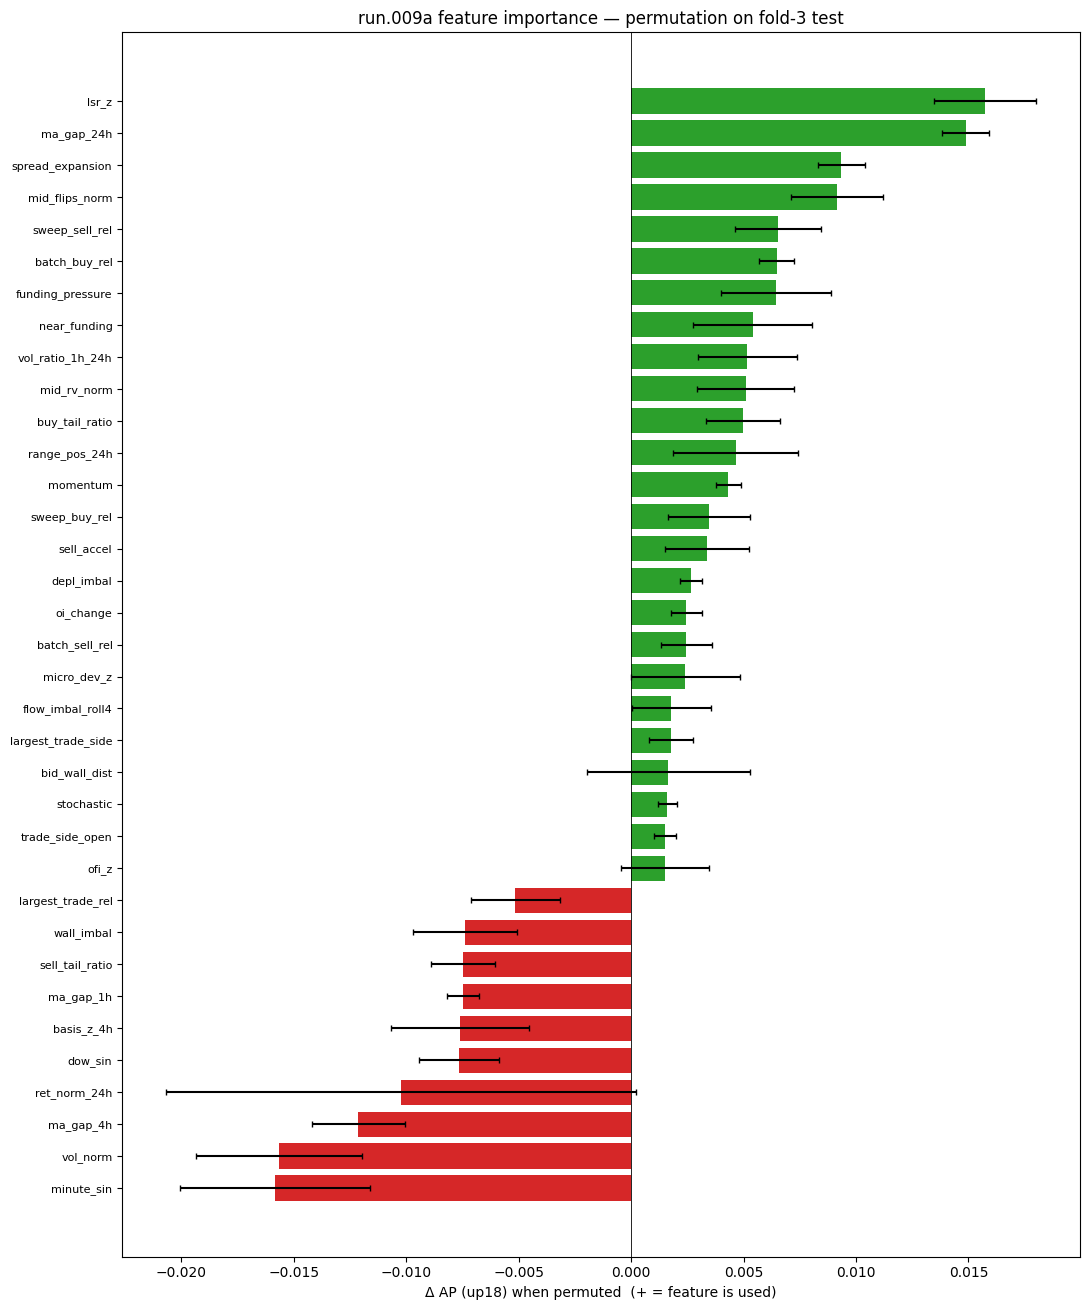

Saved -> /root/btc_lstm_run009b_importance/run009b_importance.png


In [20]:
# ── Plot: per-feature AP drop, top 25 + bottom 10 ─────────────────────────
top = imp.head(25)
bot = imp.tail(10)
sel = pd.concat([top, bot]).drop_duplicates('feature')
fig, ax = plt.subplots(figsize=(11, 0.32 * len(sel) + 2))
y = np.arange(len(sel))
colors = ['tab:green' if v > 0 else 'tab:red' for v in sel['ap_up18_drop']]
ax.barh(y, sel['ap_up18_drop'], xerr=sel['ap_up18_sd'], color=colors, capsize=2)
ax.set_yticks(y); ax.set_yticklabels(sel['feature'], fontsize=8)
ax.invert_yaxis(); ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel(f'\u0394 AP (up{H_SEL}) when permuted  (+ = feature is used)')
ax.set_title('run.009a feature importance — permutation on fold-%d test' % EVAL_FOLD)
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'run009b_importance.png')
plt.savefig(plot_path, dpi=110, bbox_inches='tight')
plt.show()
print(f'Saved -> {plot_path}')


## 12. Save to Drive + how to read

In [21]:
# ── Save results to Drive ──────────────────────────────────────────────────
import shutil
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
for p in [os.path.join(OUTPUT_DIR, 'run009b_importance_per_feature.csv'),
          os.path.join(OUTPUT_DIR, 'run009b_importance_by_group.csv'),
          os.path.join(OUTPUT_DIR, 'run009b_importance_group_control.csv'),
          os.path.join(OUTPUT_DIR, 'run009b_importance_univariate.csv'),
          os.path.join(OUTPUT_DIR, 'run009b_importance.png')]:
    if os.path.exists(p):
        shutil.copy(p, DRIVE_SAVE_DIR)
        print(f'  -> Drive: {os.path.join(DRIVE_SAVE_DIR, os.path.basename(p))}')
try:
    drive.flush_and_unmount()
except Exception as e:
    print(f'  (drive unmount skipped: {e})')

print('\nHow to read this:')
print(' 1. "ap_up18_drop" is the primary ranking, measured against the POOLED noise')
print('    floor (section 7). But permutation importance is correlation-blind: a')
print('    feature whose information is duplicated elsewhere scores low even when it')
print('    matters. The below-floor list is DESCRIPTIVE ONLY - do not prune from it.')
print(' 2. Section 8 gives block drops; section 9 is their control. A block is only')
print('    special if its drop sits OUTSIDE the range of random same-size blocks.')
print(' 3. Univariate |AUC-0.5| is a model-free second opinion, but it largely measures')
print('    volatility: first-touch labels need a big move either way, so the top')
print('    features score high on BOTH up and dn. It is not directional skill.')
print(' 4. This is a DIAGNOSTIC, not a gate. It says which features the model uses,')
print('    not whether the strategy makes money. run.009a already answered that: gate')
print('    FAILED (per-fold sim 0/4). Do not read importance as economic evidence.')
print(' 5. Importance is measured on fold %d only (the saved model). For a per-fold' % EVAL_FOLD)
print('    view, rerun with EVAL_FOLD=0..3 after training each fold.')
print(' 6. To actually prune, use BLOCK ABLATION (drop the block, retrain, compare),')
print('    not the per-feature permutation ranking.')


  -> Drive: /content/drive/MyDrive/btc_lstm_run009b_importance/run009b_importance_per_feature.csv
  -> Drive: /content/drive/MyDrive/btc_lstm_run009b_importance/run009b_importance_by_group.csv
  -> Drive: /content/drive/MyDrive/btc_lstm_run009b_importance/run009b_importance_group_control.csv
  -> Drive: /content/drive/MyDrive/btc_lstm_run009b_importance/run009b_importance_univariate.csv
  -> Drive: /content/drive/MyDrive/btc_lstm_run009b_importance/run009b_importance.png

How to read this:
 1. "ap_up18_drop" is the primary ranking, measured against the POOLED noise
    floor (section 7). But permutation importance is correlation-blind: a
    feature whose information is duplicated elsewhere scores low even when it
    matters. The below-floor list is DESCRIPTIVE ONLY - do not prune from it.
 2. Section 8 gives block drops; section 9 is their control. A block is only
    special if its drop sits OUTSIDE the range of random same-size blocks.
 3. Univariate |AUC-0.5| is a model-free secon

## Notes / caveats

- **Fold coverage.** The Drive checkpoint holds only the **last** fold's models + scaler (run.009a cell 15 saves `results[-1]`). Importance is measured on fold 3 — the newest, largest-train, highest-IC fold. Raise `N_REPEATS` and re-run with `EVAL_FOLD` 0–3 (retraining) for per-regime stability.
- **Permutation importance is correlation-blind.** A feature whose information is duplicated by a correlated feature scores low even when it matters. Concretely, `vol_norm` is the strongest univariate feature (AUC 0.91 on both up and dn labels) yet falls below the permutation noise floor, because the same volatility information is available from `mid_rv_norm`, `depl_total_norm`, `vol_ratio_1h_24h`, and others. **The "not distinguishable from noise" list is descriptive only — do not prune from it.** Prune with block ablation instead.
- **The grouped drops need the control.** Permuting k features removes k inputs' worth of information no matter which k they are, so a large block can drop a lot simply by being big. §9 draws `N_RANDOM_CONTROLS` random size-matched blocks from the other features; a block is only special if its drop sits outside that random range.
- **Univariate AUC measures volatility, not direction.** First-touch labels require a big move in *either* direction, so the top univariate features score high on both `lup_18` and `ldn_18`. That is a property of the label, not directional skill.
- **`weights_only=False` on `torch.load`.** The checkpoint contains a pickled sklearn `StandardScaler`; torch ≥ 2.6 defaults to `weights_only=True` and would refuse it.
- **Subsampling.** `N_EVAL=20000` windows ≈ 1.2 GB. The full fold-3 test set (~165k) is ~9.6 GB of windows — do not set `N_EVAL=0` on a standard Colab runtime.
- **Runtime.** Each permuted evaluation is `n_repeats x n_seeds` forward passes. At `N_EVAL=20000`, `N_REPEATS=8`, 3 seeds, the per-feature sweep is ~15 min, the grouped + control pass ~10 min.
- **Cells 1–9 are byte-identical to `btc_lstm.run.009a.ipynb`** except `OUTPUT_DIR`/`DRIVE_SAVE_DIR`. The only new logic is the cells below them.
